<a href="https://colab.research.google.com/github/MrGladiator14/notebooks/blob/main/cnn_eagle_img.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision matplotlib pillow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from skimage import data, transform


In [ ]:
model = VGG16(weights='imagenet', include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step


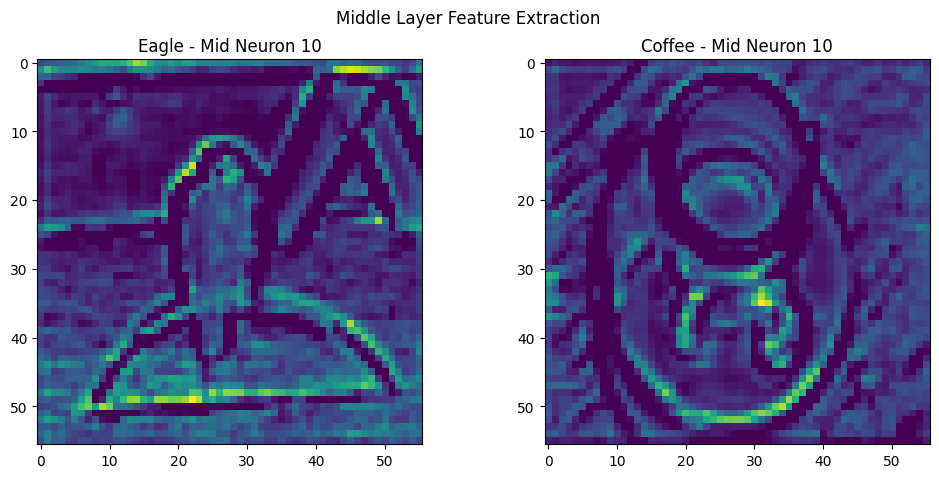

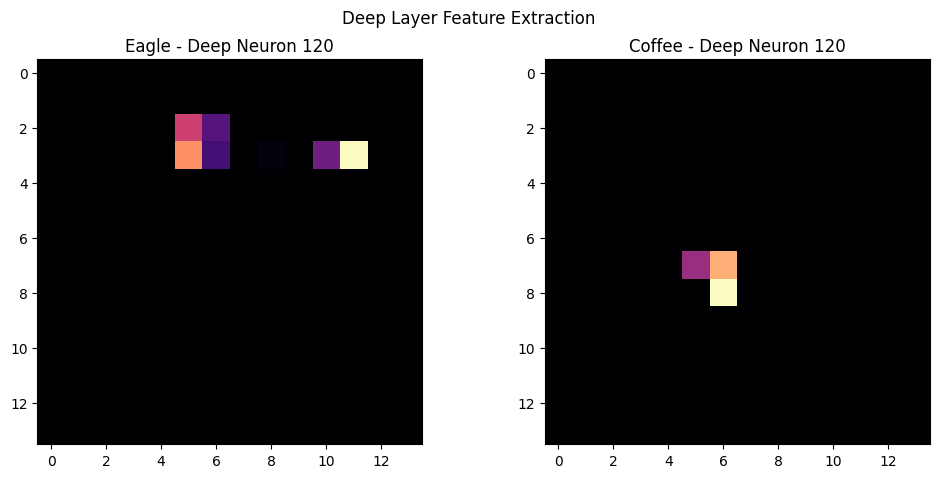

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
import tensorflow as tf

# 1. Prepare images
def prepare_image(img_raw):
    img_resized = transform.resize(img_raw, (224, 224))
    if img_resized.ndim == 2:
        img_resized = np.stack([img_resized] * 3, axis=-1)
    x = np.expand_dims(img_resized * 255, axis=0)
    return preprocess_input(x)

img_eagle = data.eagle()
img_coffee = data.coffee()

x_eagle = prepare_image(img_eagle)
x_coffee = prepare_image(img_coffee)

# 2. Define models for specific layers
mid_layer_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer('block3_conv1').output)
deep_layer_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer('block5_conv3').output)

# 3. Get features
mid_features_eagle = mid_layer_model.predict(x_eagle)
mid_features_coffee = mid_layer_model.predict(x_coffee)

deep_features_eagle = deep_layer_model.predict(x_eagle)
deep_features_coffee = deep_layer_model.predict(x_coffee)

# 4. Visualize Mid Layer Neurons (Comparison)
neuron_idx = 10
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(mid_features_eagle[0, :, :, neuron_idx], cmap='viridis')
ax[0].set_title(f"Eagle - Mid Neuron {neuron_idx}")
ax[1].imshow(mid_features_coffee[0, :, :, neuron_idx], cmap='viridis')
ax[1].set_title(f"Coffee - Mid Neuron {neuron_idx}")
plt.suptitle("Middle Layer Feature Extraction")
plt.show()

# 5. Visualize Deep Layer Neurons (Comparison)
neuron_idx_deep = 120
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(deep_features_eagle[0, :, :, neuron_idx_deep], cmap='magma')
ax[0].set_title(f"Eagle - Deep Neuron {neuron_idx_deep}")
ax[1].imshow(deep_features_coffee[0, :, :, neuron_idx_deep], cmap='magma')
ax[1].set_title(f"Coffee - Deep Neuron {neuron_idx_deep}")
plt.suptitle("Deep Layer Feature Extraction")
plt.show()

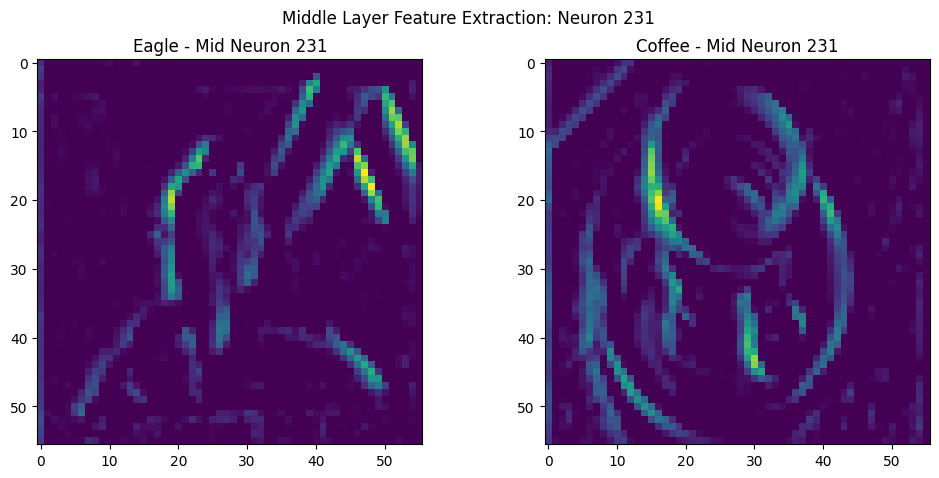

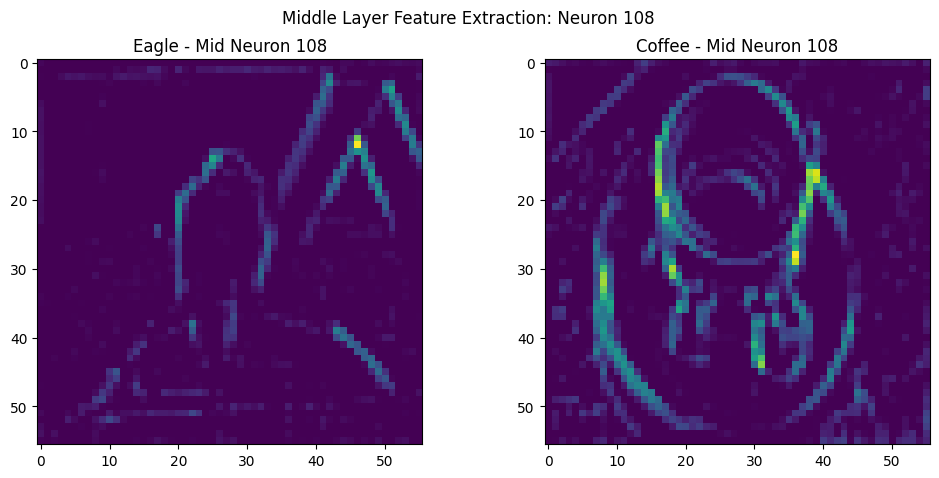

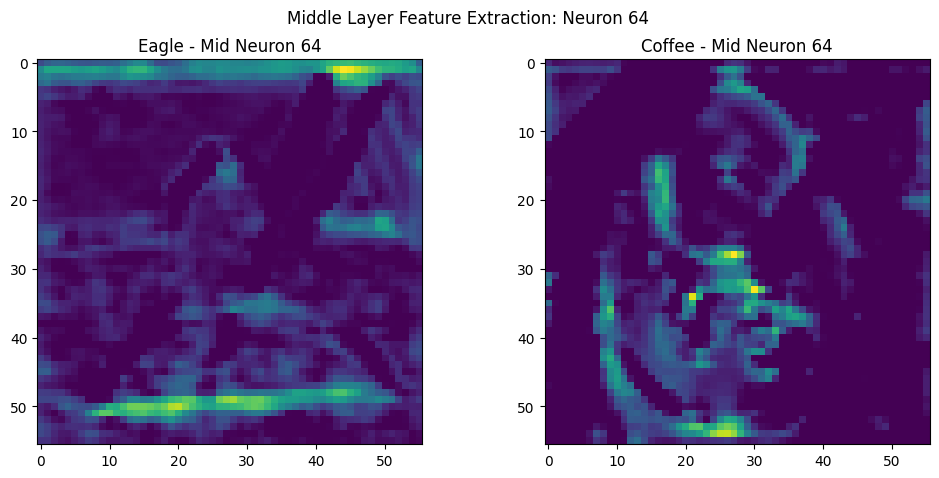

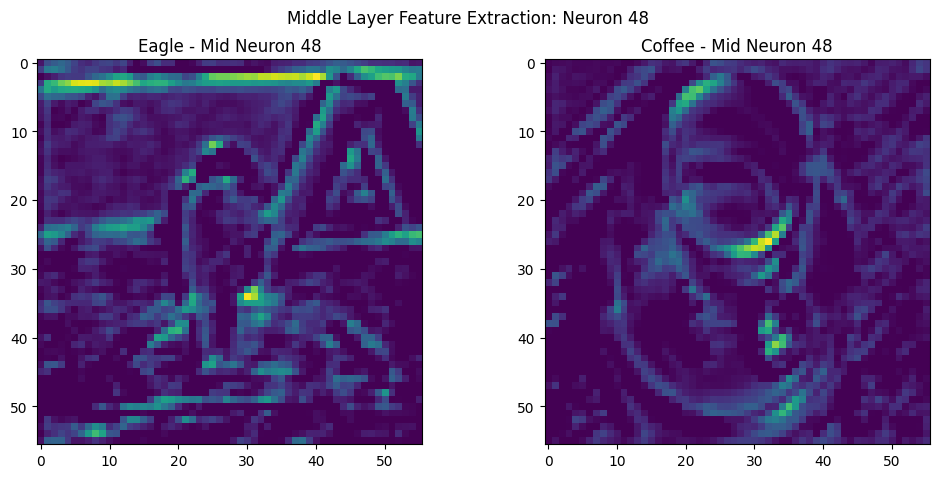

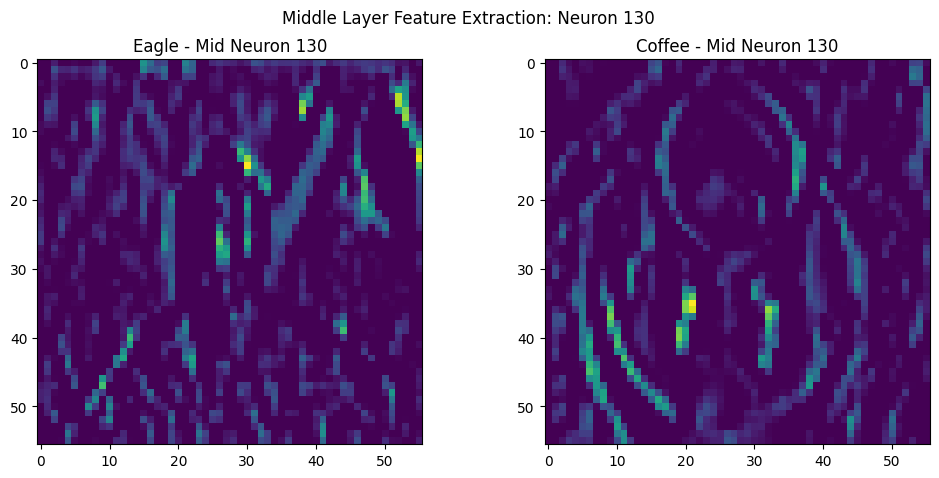

In [22]:
import random

for idx in random.sample(range(mid_features_eagle.shape[-1]), 5):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(mid_features_eagle[0, :, :, idx], cmap='viridis')
    ax[0].set_title(f'Eagle - Mid Neuron {idx}')
    ax[1].imshow(mid_features_coffee[0, :, :, idx], cmap='viridis')
    ax[1].set_title(f'Coffee - Mid Neuron {idx}')
    plt.suptitle(f'Middle Layer Feature Extraction: Neuron {idx}')
    plt.show()

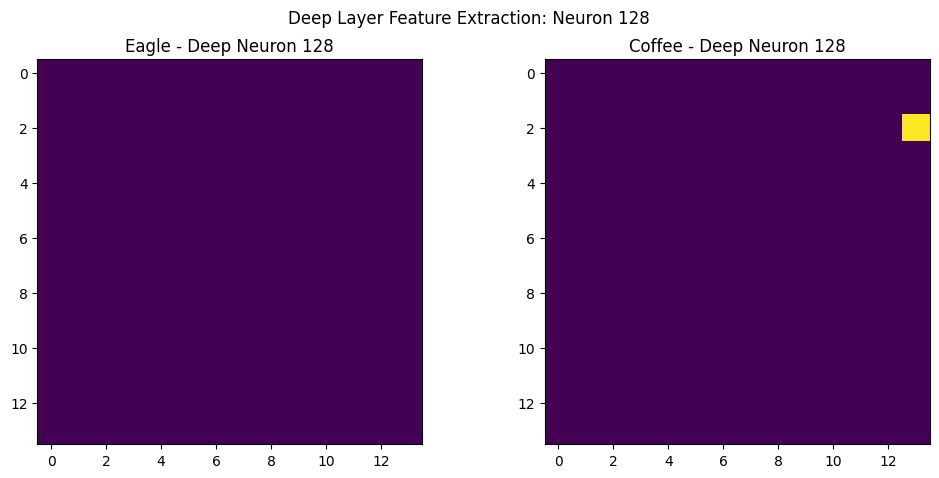

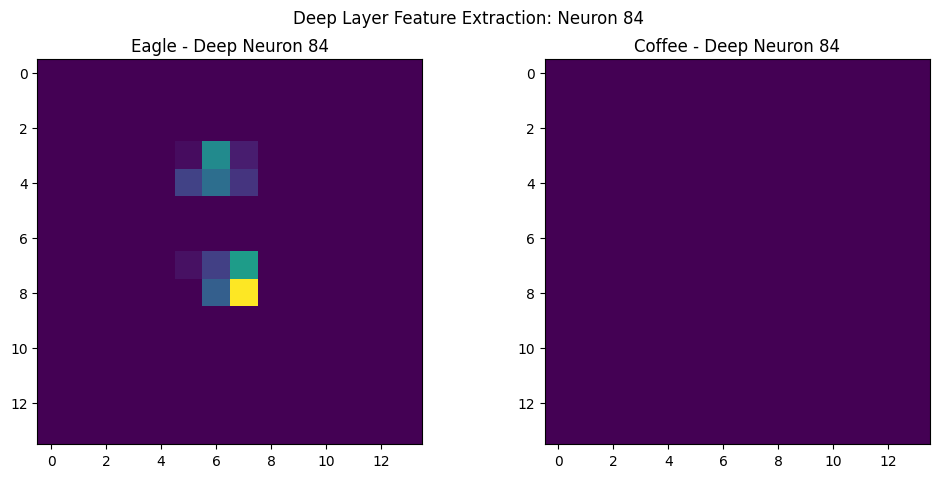

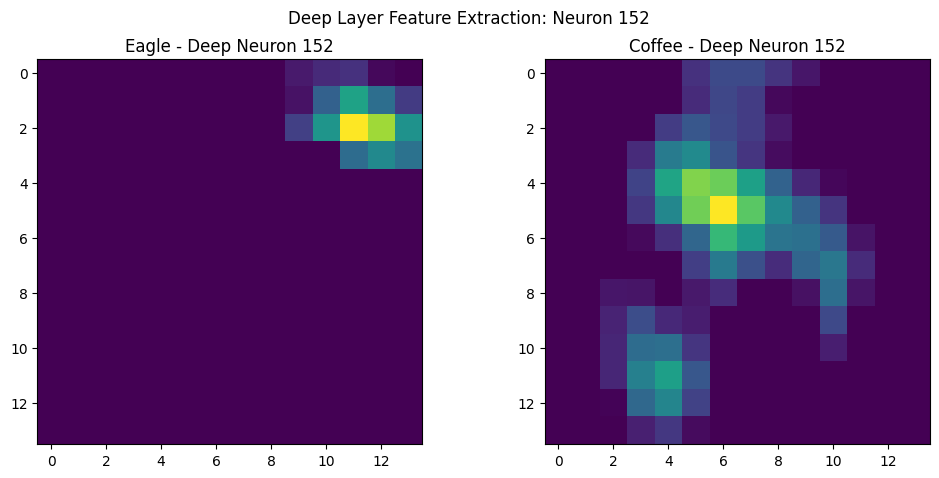

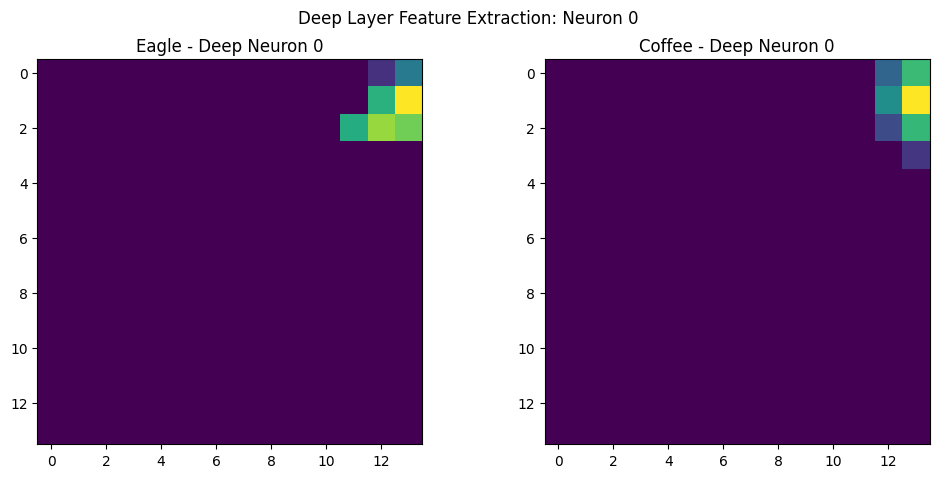

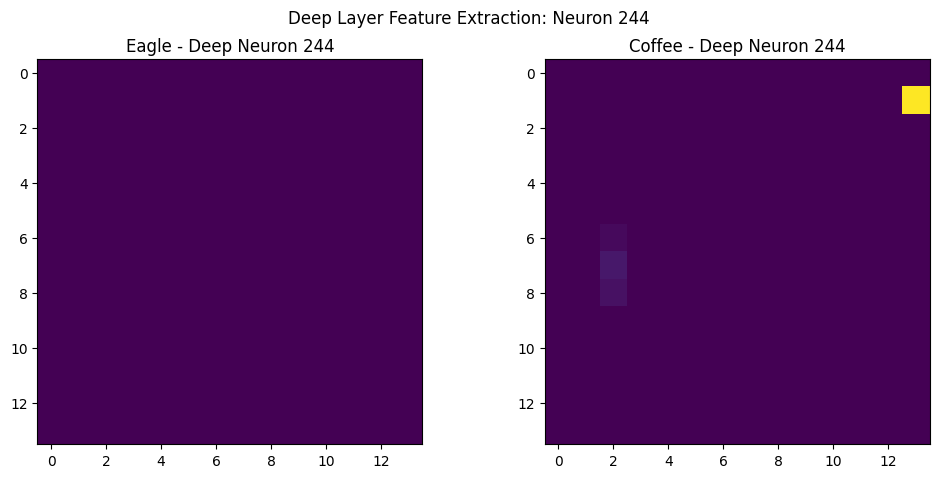

In [23]:
# Visualize Deep Layer Neurons 17 and 18 for comparison
for idx in random.sample(range(mid_features_eagle.shape[-1]), 5):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(deep_features_eagle[0, :, :, idx], cmap='viridis')
    ax[0].set_title(f'Eagle - Deep Neuron {idx}')
    ax[1].imshow(deep_features_coffee[0, :, :, idx], cmap='viridis')
    ax[1].set_title(f'Coffee - Deep Neuron {idx}')
    plt.suptitle(f'Deep Layer Feature Extraction: Neuron {idx}')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


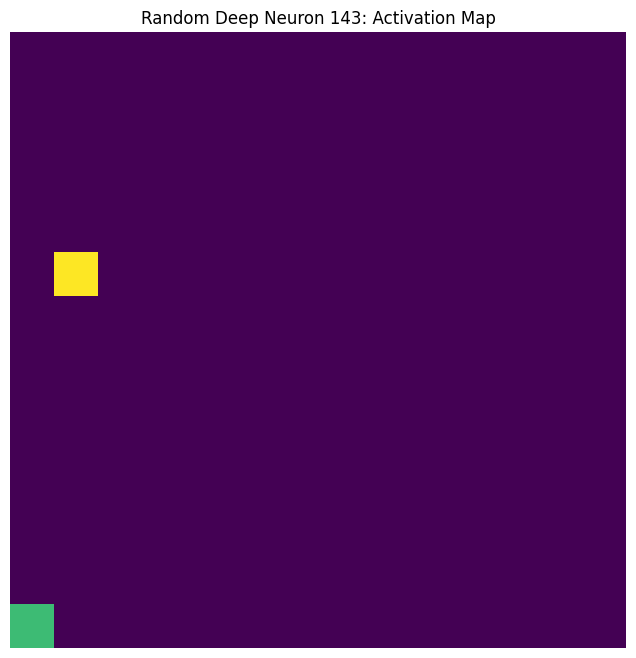

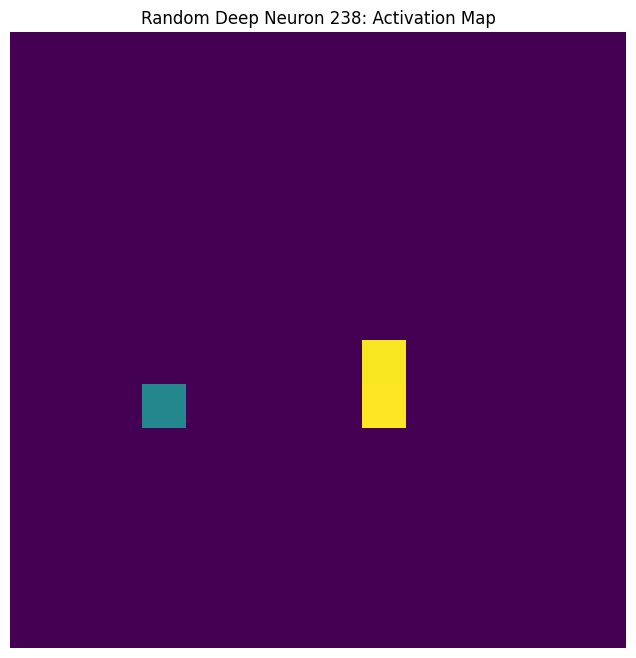

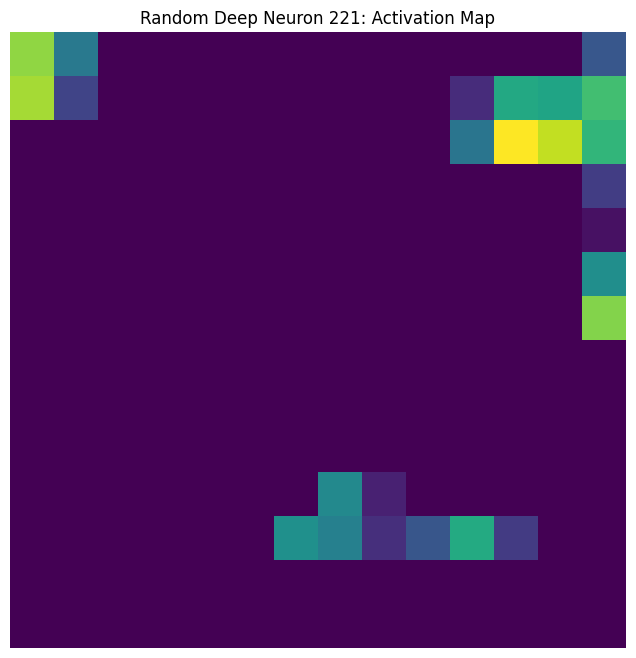

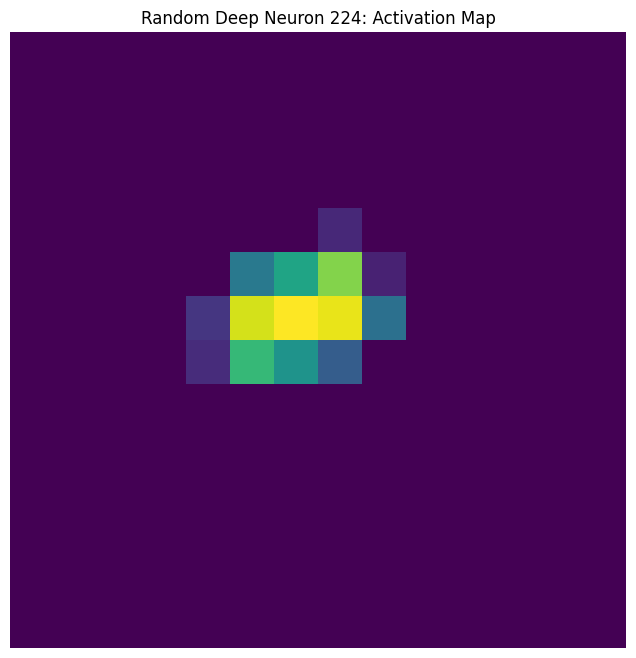

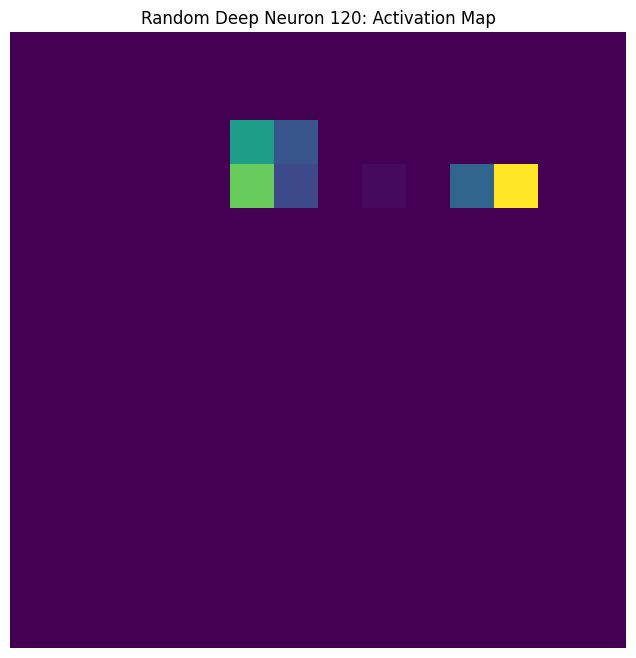

In [ ]:
# 2. find a 'specialist' neuron
# In deep layers, many filters will be blank, but some will 'glow' intensively
# on specific parts of the astronaut's image
num_neurons = mid_features.shape[-1]
for _ in range(5):
  # Select a random neuron index
  random_neuron_idx = random.randint(0, num_neurons - 1)

  # Plot the randomly selected neuron
  plt.figure(figsize=(8,8))
  plt.imshow(deep_features[0,:,:,random_neuron_idx], cmap='viridis')
  plt.title(f"Random Deep Neuron {random_neuron_idx}: Activation Map")
  plt.axis('off')
  plt.show()
